# 09 — Descriptivos de subcategorías de salud

Equivalente al notebook `11_descriptivos_diccionarios_literatura.ipynb` de Karen,  
adaptado al dominio de salud: analiza la distribución y evolución de las  
13 subcategorías de salud detectadas en el corpus.

**Entrada:** `salud_tweets_final.parquet`, `corpus_cleaned.parquet`  
**Salida:** `descriptivos_subcategorias_salud.xlsx`, figuras

In [1]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento')

# Columnas de subcategorías (scores del clasificador)
COLS_SUBCATS = [
    'Comp_Lavado_manos',
    'Comp_Desinfectante',
    'Comp_Mascarilla',
    'Comp_Etiqueta_tos_codo',
    'Comp_Etiqueta_tos_panuelo',
    'Comp_Distanciamiento',
    'Comp_Evitar_reuniones',
]

# Etiquetas cortas para gráficos
LABELS_CORTOS = {
    'Comp_Lavado_manos'        : 'Lavado manos',
    'Comp_Desinfectante'       : 'Desinfectante',
    'Comp_Mascarilla'          : 'Mascarilla',
    'Comp_Etiqueta_tos_codo'   : 'Tos codo',
    'Comp_Etiqueta_tos_panuelo': 'Tos panñuelo',
    'Comp_Distanciamiento'     : 'Distanciamiento',
    'Comp_Evitar_reuniones'    : 'Evitar reuniones',
}

print('[CONFIG] OK')


[CONFIG] OK


In [2]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import unicodedata
import warnings
warnings.filterwarnings('ignore')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Subcorpus de comportamientos — merge incluye Fecha
df = pd.read_parquet(DATA_PROCESSED / 'comportamiento_tweets_final.parquet')
df = df.merge(
    corpus[['id_doc', 'Author_Normalized', 'Entidad', 'Fecha', 'Texto_limpio']],
    on='id_doc', how='left'
)
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
df['Anio']  = df['Fecha'].dt.year

print(f'Corpus completo     : {len(corpus):,} tweets')
print(f'Subcorpus comp.     : {len(df):,} tweets')
print(f'Subcategorias       : {len(COLS_SUBCATS)}')
df.head(2)


Corpus completo     : 151,424 tweets
Subcorpus comp.     : 2,804 tweets
Subcategorias       : 7


,chunk_id,id_doc,texto_chunk,Comp_Desinfectante,Comp_Distanciamiento,Comp_Etiqueta_tos_codo,Comp_Etiqueta_tos_panuelo,Comp_Evitar_reuniones,Comp_Lavado_manos,Comp_Mascarilla,score_max,subcat_max,etiqueta_comportamiento,categoria_detectada,Author_Normalized,Entidad,Fecha,Texto_limpio,Anio
0,17_1,17,A esas horas el covid19 se queda en la casa mi...,0.037909,0.313174,0.314862,0.321228,0.509031,0.192823,0.118177,0.509031,Comp_Evitar_reuniones,1,Comp_Evitar_reuniones,@elima2219,Sin descripción,2020-06-03,A esas horas el covid19 se queda en la casa mi...,2020
1,67_1,67,Los vendedores de balones de oxígeno y las pla...,0.253668,0.146621,0.448458,0.501524,0.200239,0.224089,0.342172,0.501524,Comp_Etiqueta_tos_panuelo,1,Comp_Etiqueta_tos_panuelo,@cmalcagmailcom1,Sin descripción,2020-06-03,Los vendedores de balones de oxígeno y las pla...,2020


In [3]:
# ============================================================
# CELL 2 — DISTRIBUCIÓN GENERAL DE SUBCATEGORÍAS
# ============================================================

# Frecuencia por subcategoría (subcat_max = subcategoría dominante por tweet)
freq_subcat = (
    df['subcat_max']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Subcategoria', 'subcat_max': 'Frecuencia'})
)
# compatibilidad pandas
freq_subcat.columns = ['Subcategoria', 'Frecuencia']
freq_subcat['Porcentaje'] = (freq_subcat['Frecuencia'] / len(df) * 100).round(2)
freq_subcat['Label'] = freq_subcat['Subcategoria'].map(LABELS_CORTOS).fillna(freq_subcat['Subcategoria'])

print(freq_subcat.to_string(index=False))


             Subcategoria  Frecuencia  Porcentaje            Label
    Comp_Evitar_reuniones        1193       42.55 Evitar reuniones
   Comp_Etiqueta_tos_codo         775       27.64         Tos codo
Comp_Etiqueta_tos_panuelo         313       11.16     Tos panñuelo
        Comp_Lavado_manos         264        9.42     Lavado manos
          Comp_Mascarilla         144        5.14       Mascarilla
     Comp_Distanciamiento          76        2.71  Distanciamiento
       Comp_Desinfectante          39        1.39    Desinfectante


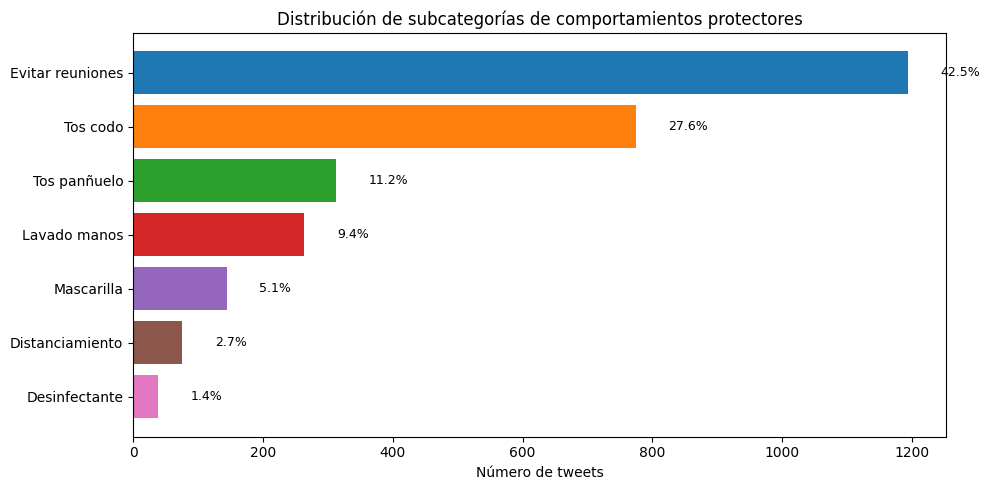

[GUARDADO] fig_distribucion_subcategorias_comp_detalle.png


In [4]:
# ============================================================
# CELL 3 — GRÁFICO BARRAS DISTRIBUCIÓN SUBCATEGORÍAS
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("tab10", len(freq_subcat))
bars = ax.barh(freq_subcat['Label'], freq_subcat['Frecuencia'], color=palette)

for bar, pct in zip(bars, freq_subcat['Porcentaje']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

ax.set_title('Distribución de subcategorías de comportamientos protectores')
ax.set_xlabel('Número de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_distribucion_subcategorias_comp_detalle.png', dpi=300)
plt.show()
print('[GUARDADO] fig_distribucion_subcategorias_comp_detalle.png')


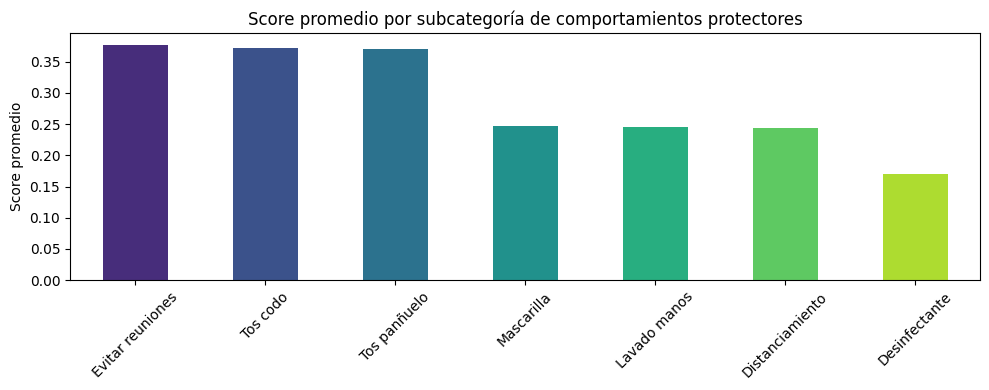

[GUARDADO] fig_scores_promedio_subcat_comp.png


In [5]:
# ============================================================
# CELL 4 — SCORES PROMEDIO POR SUBCATEGORÍA
# (muestra intensidad del clasificador, no solo el dominante)
# ============================================================
scores_prom = df[COLS_SUBCATS].mean().rename(LABELS_CORTOS)
scores_prom = scores_prom.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
scores_prom.plot(kind='bar', ax=ax, color=sns.color_palette("viridis", len(scores_prom)))
ax.set_title('Score promedio por subcategoría de comportamientos protectores')
ax.set_ylabel('Score promedio')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_scores_promedio_subcat_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_scores_promedio_subcat_comp.png')


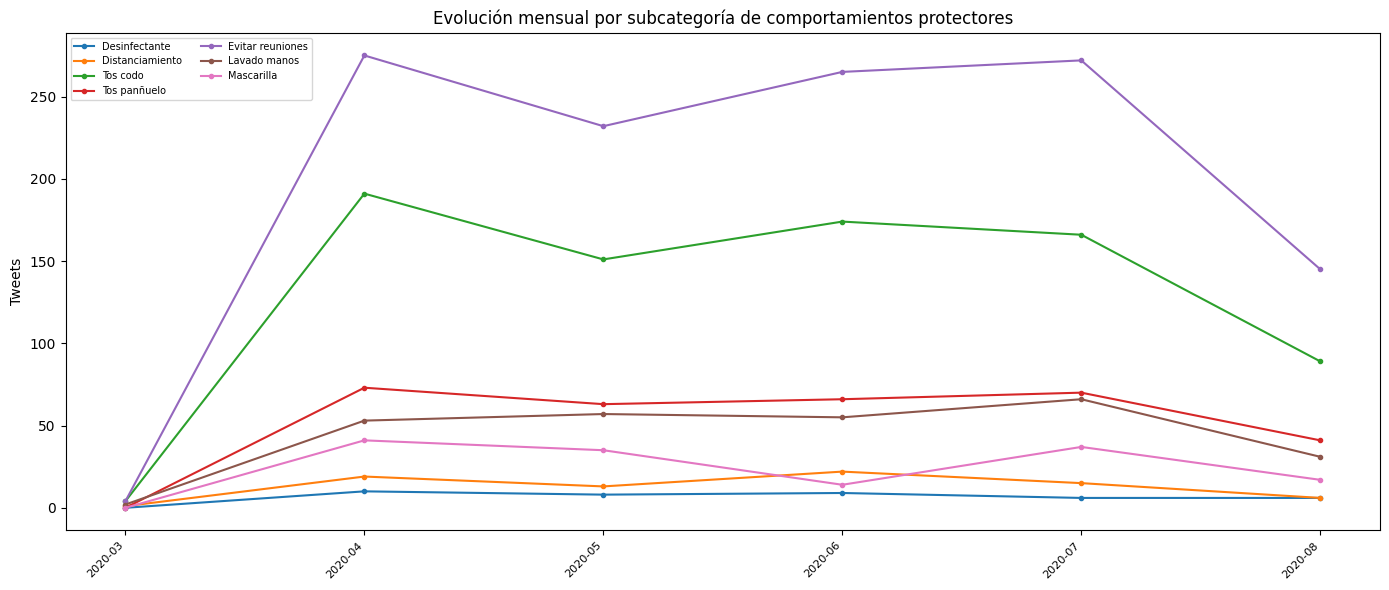

[GUARDADO] fig_evolucion_subcategorias_comp.png


In [6]:
# ============================================================
# CELL 5 — EVOLUCIÓN TEMPORAL POR SUBCATEGORÍA
# ============================================================
df['anio_mes'] = df['Fecha'].dt.to_period('M').astype(str)

evol = (
    df.groupby(['anio_mes', 'subcat_max'])
    .size()
    .reset_index(name='n')
)

# Pivot para tener una columna por subcategoría
evol_pivot = evol.pivot(index='anio_mes', columns='subcat_max', values='n').fillna(0)
evol_pivot.columns = [LABELS_CORTOS.get(c, c) for c in evol_pivot.columns]
evol_pivot = evol_pivot.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
for col in evol_pivot.columns:
    ax.plot(evol_pivot.index, evol_pivot[col], marker='o', markersize=3, label=col)

ax.set_title('Evolución mensual por subcategoría de comportamientos protectores')
ax.set_ylabel('Tweets')
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=7, ncol=2)
step = max(1, len(evol_pivot) // 12)
ax.set_xticks(range(0, len(evol_pivot), step))
ax.set_xticklabels(evol_pivot.index[::step], rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_evolucion_subcategorias_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_evolucion_subcategorias_comp.png')


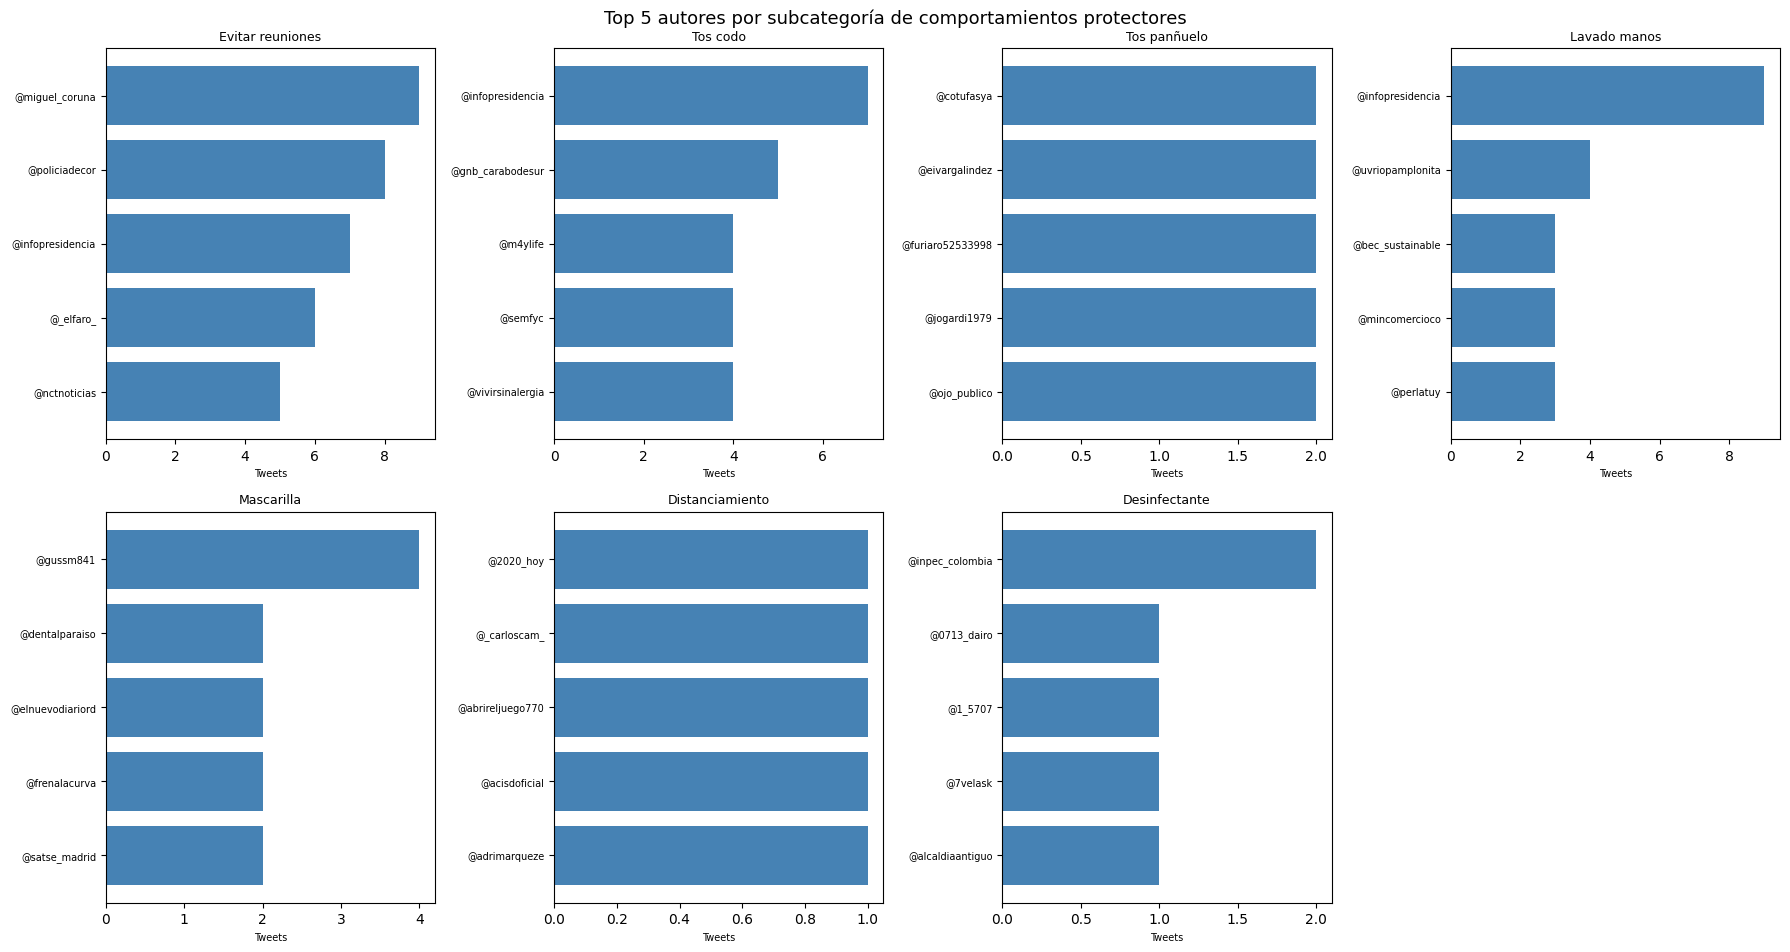

[GUARDADO] fig_autores_por_subcat_comp.png


In [7]:
# ============================================================
# CELL 6 — AUTORES MÁS ACTIVOS POR SUBCATEGORÍA
# ============================================================
top_autores_subcat = (
    df.groupby(['subcat_max', 'Author_Normalized'])
    .size()
    .reset_index(name='n')
    .sort_values(['subcat_max', 'n'], ascending=[True, False])
)
top5_por_subcat = top_autores_subcat.groupby('subcat_max').head(5)
top5_por_subcat['Label'] = top5_por_subcat['subcat_max'].map(LABELS_CORTOS).fillna(top5_por_subcat['subcat_max'])

subcats_orden = freq_subcat['Subcategoria'].tolist()
n_subcats = len(subcats_orden)
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for i, subcat in enumerate(subcats_orden):
    ax = axes[i]
    subset = top5_por_subcat[top5_por_subcat['subcat_max'] == subcat].head(5)
    if subset.empty:
        ax.set_visible(False)
        continue
    ax.barh(subset['Author_Normalized'], subset['n'], color='steelblue')
    ax.set_title(LABELS_CORTOS.get(subcat, subcat), fontsize=9)
    ax.set_xlabel('Tweets', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

for j in range(n_subcats, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 5 autores por subcategoría de comportamientos protectores', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_autores_por_subcat_comp.png', dpi=300)
plt.show()
print('[GUARDADO] fig_autores_por_subcat_comp.png')


In [8]:
# ============================================================
# CELL 7 — NORMALIZACIÓN (sin tildes) Y VERIFICACIÓN
# (Replica de Karen: normalizar texto para comparaciones)
# ============================================================
import unicodedata

def normalizar(texto):
    if pd.isna(texto):
        return texto
    texto = str(texto).strip()
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    return texto

# Verificar solapamiento entre subcategorías con scores altos
umbral = 0.5
solapamiento = {}
for i, col_a in enumerate(COLS_SUBCATS):
    for col_b in COLS_SUBCATS[i+1:]:
        n = ((df[col_a] >= umbral) & (df[col_b] >= umbral)).sum()
        if n > 0:
            solapamiento[f"{LABELS_CORTOS[col_a]} ∩ {LABELS_CORTOS[col_b]}"] = n

if solapamiento:
    df_sol = pd.DataFrame(list(solapamiento.items()), columns=['Par', 'N_tweets'])
    df_sol = df_sol.sort_values('N_tweets', ascending=False)
    print(f'Pares con solapamiento (score >= {umbral}):')
    print(df_sol.to_string(index=False))
else:
    print('Sin solapamientos significativos a umbral', umbral)


Pares con solapamiento (score >= 0.5):
                               Par  N_tweets
           Tos codo ∩ Tos panñuelo       222
      Lavado manos ∩ Desinfectante        57
Distanciamiento ∩ Evitar reuniones        43
       Lavado manos ∩ Tos panñuelo        33
           Lavado manos ∩ Tos codo        15
      Desinfectante ∩ Tos panñuelo         9
             Mascarilla ∩ Tos codo         8
          Desinfectante ∩ Tos codo         4
         Mascarilla ∩ Tos panñuelo         4
       Tos codo ∩ Evitar reuniones         4
         Lavado manos ∩ Mascarilla         2
   Lavado manos ∩ Evitar reuniones         2
   Tos panñuelo ∩ Evitar reuniones         2
        Desinfectante ∩ Mascarilla         1


In [9]:
# ============================================================
# CELL 8 — GUARDAR TABLAS
# ============================================================
ruta_excel = DATA_PROCESSED / 'descriptivos_subcategorias_comportamiento.xlsx'

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_subcat.to_excel(writer, sheet_name='Frecuencia_subcat', index=False)
    scores_prom.reset_index().rename(columns={'index': 'Subcategoria', 0: 'Score_promedio'}).to_excel(
        writer, sheet_name='Scores_promedio', index=False
    )
    evol_pivot.reset_index().to_excel(writer, sheet_name='Evolucion_mensual', index=False)
    top5_por_subcat.to_excel(writer, sheet_name='Top5_autores_subcat', index=False)

print('[GUARDADO] descriptivos_subcategorias_comportamiento.xlsx')
print()
print('Notebook 09 completado.')
print('Siguiente -> 10_busqueda_lugares_instituciones.ipynb')


[GUARDADO] descriptivos_subcategorias_comportamiento.xlsx

Notebook 09 completado.
Siguiente -> 10_busqueda_lugares_instituciones.ipynb
